In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/11_Projects/chennai_reservoir_levels.csv')
df

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0
...,...,...,...,...,...
5642,13-06-2019,30.0,0.0,0.0,1.0
5643,14-06-2019,28.0,0.0,0.0,1.0
5644,15-06-2019,27.0,0.0,0.0,1.0
5645,16-06-2019,26.0,0.0,0.0,1.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             5647 non-null   object 
 1   POONDI           5647 non-null   float64
 2   CHOLAVARAM       5647 non-null   float64
 3   REDHILLS         5647 non-null   float64
 4   CHEMBARAMBAKKAM  5647 non-null   float64
dtypes: float64(4), object(1)
memory usage: 220.7+ KB


In [38]:
type(df['Date'][0])

str

In [39]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   POONDI           5647 non-null   float64       
 2   CHOLAVARAM       5647 non-null   float64       
 3   REDHILLS         5647 non-null   float64       
 4   CHEMBARAMBAKKAM  5647 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 220.7 KB


In [40]:
df.columns

Index(['Date', 'POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM'], dtype='object')

In [41]:
df['Total'] = df[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].sum(axis=1)
df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total
0,2004-01-01,3.9,0.0,268.0,0.0,271.9
1,2004-01-02,3.9,0.0,268.0,0.0,271.9
2,2004-01-03,3.9,0.0,267.0,0.0,270.9
3,2004-01-04,3.9,0.0,267.0,0.0,270.9
4,2004-01-05,3.8,0.0,267.0,0.0,270.8


In [42]:
df['Year'] = df['Date'].apply(lambda x : x.year)
df['Month'] = df['Date'].apply(lambda x : x.month)
df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total,Year,Month
0,2004-01-01,3.9,0.0,268.0,0.0,271.9,2004,1
1,2004-01-02,3.9,0.0,268.0,0.0,271.9,2004,1
2,2004-01-03,3.9,0.0,267.0,0.0,270.9,2004,1
3,2004-01-04,3.9,0.0,267.0,0.0,270.9,2004,1
4,2004-01-05,3.8,0.0,267.0,0.0,270.8,2004,1


In [51]:
Yearwise = df.groupby('Year',as_index=False).mean()


In [52]:
Yearwise = Yearwise[['Year','POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM','Total']]
Yearwise

,Year,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total
0,2004,77.766967,19.060109,220.899180,68.683060,386.409317
1,2005,722.680603,147.771781,1468.480712,581.345205,2920.278301
2,2006,1827.553425,484.947945,2044.356164,2075.317808,6432.175342
3,2007,1794.912329,286.391781,2356.654795,1715.126027,6153.084932
4,2008,1862.338798,545.609290,2445.161202,2196.967213,7050.076503
5,2009,1846.221918,414.882110,1969.731205,1795.677123,6026.512356
6,2010,1651.523288,382.175342,2045.271233,2020.501370,6099.471233
7,2011,2399.068493,499.509589,2573.326027,2492.282192,7964.186301
8,2012,1742.816940,225.934426,1872.218579,1571.677596,5412.647541
9,2013,536.953425,100.049315,1324.109589,988.964384,2950.076712


/tmp/ipython-input-1731232639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year',y='Total',data=Yearwise, palette='Set2')


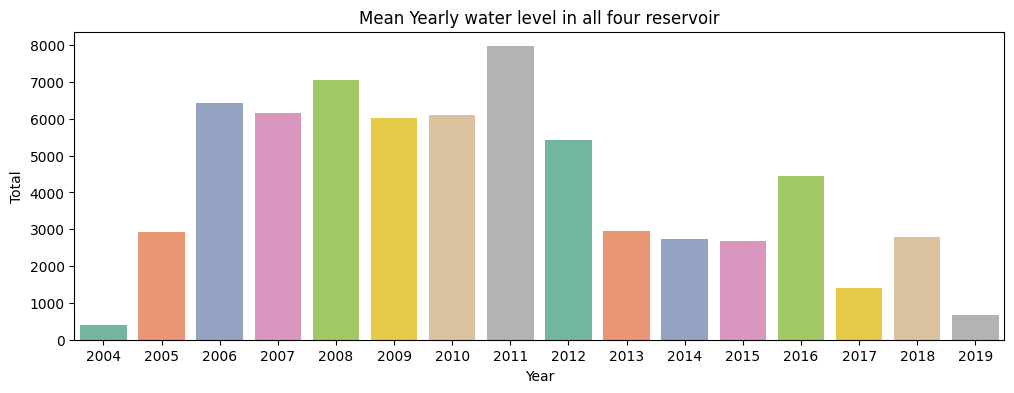

In [59]:
plt.figure(figsize=(12,4))
sns.barplot(x='Year',y='Total',data=Yearwise, palette='Set2')
plt.title('Mean Yearly water level in all four reservoir')
plt.show()

<Axes: xlabel='Year'>

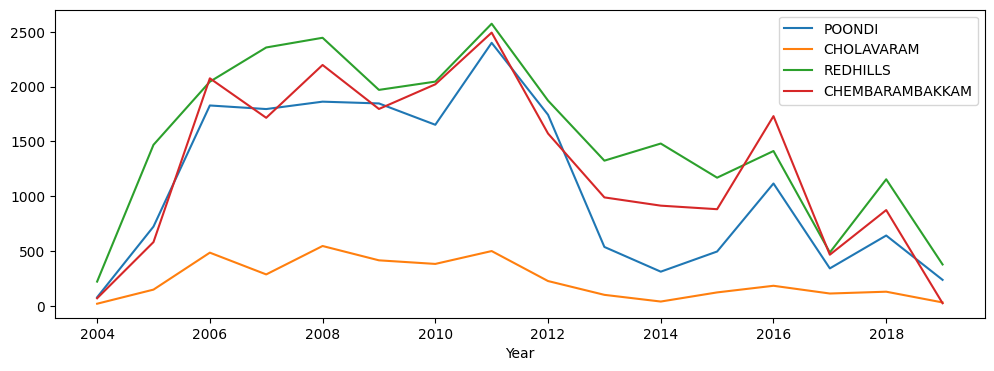

In [63]:
Yearwise.plot(x='Year', y=['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM'],figsize=(12,4))

In [65]:
df['Month'] = pd.Categorical(df['Month'])
df['Year'] = pd.Categorical(df['Year'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   POONDI           5647 non-null   float64       
 2   CHOLAVARAM       5647 non-null   float64       
 3   REDHILLS         5647 non-null   float64       
 4   CHEMBARAMBAKKAM  5647 non-null   float64       
 5   Total            5647 non-null   float64       
 6   Year             5647 non-null   category      
 7   Month            5647 non-null   category      
dtypes: category(2), datetime64[ns](1), float64(5)
memory usage: 276.9 KB


<Axes: xlabel='Year', ylabel='Total'>

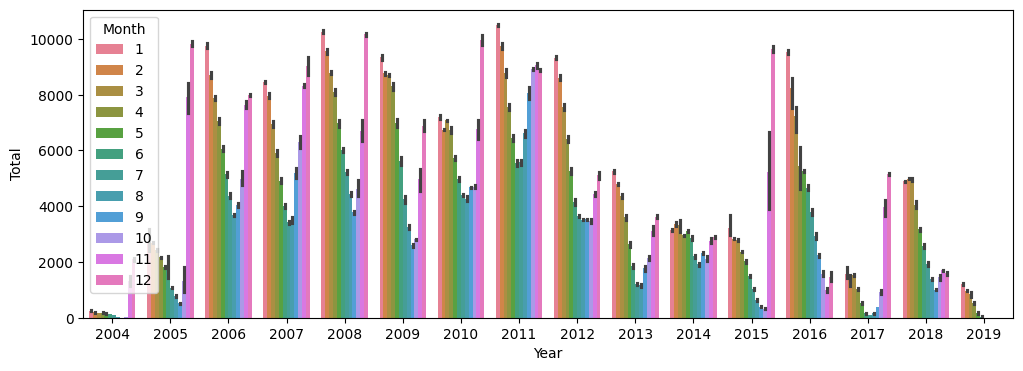

In [67]:
plt.figure(figsize=(12,4))
sns.barplot(x='Year',y='Total',data=df,hue='Month')

/tmp/ipython-input-1589373293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year',y='Total',data=jan, palette='Set2')


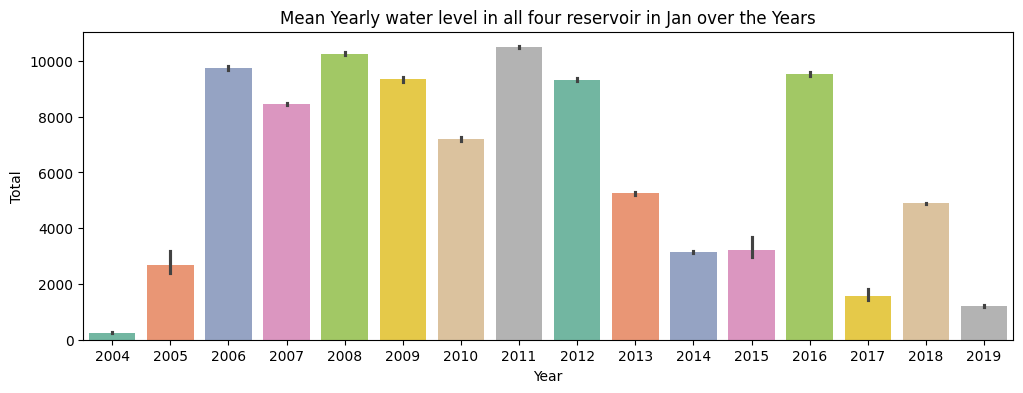

In [70]:
jan = df[df['Month'] == 1]
plt.figure(figsize=(12,4))
sns.barplot(x='Year',y='Total',data=jan, palette='Set2')
plt.title('Mean Yearly water level in all four reservoir in Jan over the Years')
plt.show()

/tmp/ipython-input-547625341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year',y='Total',data=dec, palette='Set2')


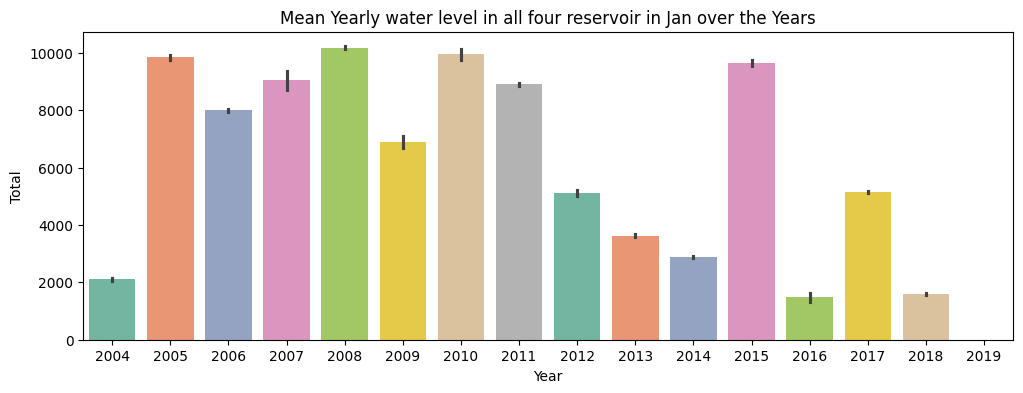

In [71]:
dec = df[df['Month'] == 12]
plt.figure(figsize=(12,4))
sns.barplot(x='Year',y='Total',data=dec, palette='Set2')
plt.title('Mean Yearly water level in all four reservoir in Jan over the Years')
plt.show()